In [1]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import cmocean as cmo 
import matplotlib as mpl 
# get dates

# Create object 
class ModelResult:
    def __init__(self, fn, start_date, end_date, isave):
        self.ds = xr.open_dataset(fn, decode_timedelta=False)
        self.nt = len(self.ds.time.values)
        self.start_day = pd.to_datetime(start_date)
        self.end_day = pd.to_datetime(end_date)
        self.dates = pd.date_range(start_date, end_date, freq="10s")
        self.dates = self.dates[::isave]
        self.dates = self.dates[0:self.nt]
        print("There are %d saved profiles in this model..." % self.nt)

isave = 100

colors = ["#a4c639", "#73c2fb", "#d1001c", "#ff7f50", "#ceffb6", "#015185", "#ff1493", "#db7093", "#c71585", "#800080"]



m1 = ModelResult("2024_heat_flux_ens100.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)

# m10 = ModelResult("2024_heat_flux_x1.0
# models_list = {'Wind x 1.0': m2024_01, 'Wind x 1.1': m2024_11, 'Wind x 0.9': m2024_09, 'Wind x 1.1 + noise (sigma=0.5)': m2024_11_noise,
#                'Wind x 1.0 + noise (sigma=0.5)': m2024_01_noise}
print(m1)
# m2024_2 = ModelResult("2024_heat_flux.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)

Nm = len(m1.ds.Nens.values)
print(Nm)

There are 87 saved profiles in this model...
100


In [2]:
# Define some plotting functions
def format_date_ax(ax, hours=2):
    """Format the x-axis of a plot with date labels."""
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=hours))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%d %H:%M"))
    ax.grid(alpha=0.25, which="both")
    # plt.setp(ax.get_xticklabels(), rotation=10, ha='right')   

def add_colorbar(fig, c):
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    cb = fig.colorbar(c, cax=cbar_ax, shrink=0.2)
    return cb 

Text(0.5, 1.0, 'Wind speed')

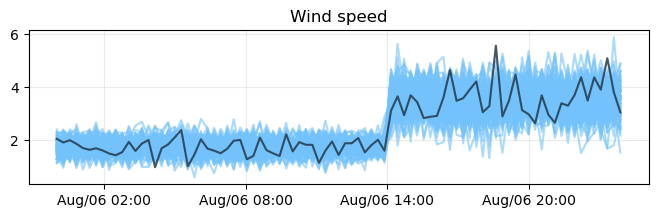

In [3]:
# Compare wind + heat forcings 
fn = "/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/"
wind_2024 = pd.read_csv(fn + "wind.csv")
heat_2024 = pd.read_csv(fn + "heat_flux2.csv")

fig2, ax2 = plt.subplots( figsize=(8, 2))

for i in range(Nm):
    ds = m1.ds.isel(Nens=i)
    ax2.plot(m1.dates, ds['wind'], color=colors[1], alpha=0.6)
    # c1 = axs[im].pcolormesh(models_list[model].dates,-m2024_11.ds.z, m2024_11.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)

# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ds = m1.ds.isel(Nens=0)
ax2.plot(m1.dates, ds['wind'], color='k', alpha=0.6)

format_date_ax(ax2, hours=6)
ax2.set_title("Wind speed")




(0.0, 5.0)

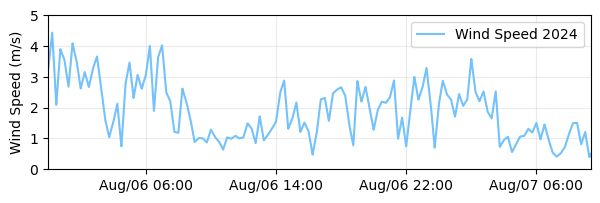

In [4]:
fig, axs = plt.subplots(1,1, figsize=(7, 2), sharex=False, sharey=True)
wtime = pd.to_datetime(wind_2024["time"])
axs.plot(wtime, wind_2024["WindSpeed"], label="Wind Speed 2024", color=colors[1])

format_date_ax(axs, hours=8)
axs.legend(loc="upper right") 
axs.set_ylabel("Wind Speed (m/s)")
axs.set_xlim(wtime[0], wtime[12000])
axs.set_ylim(0,5)



Text(0.5, 1.0, 'Average temp (top 2 m)')

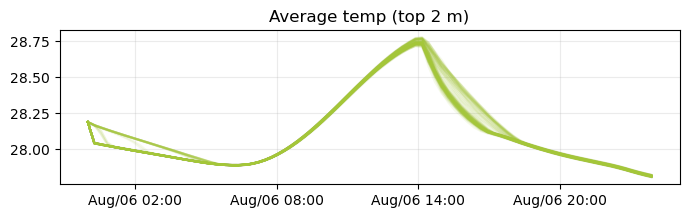

In [5]:
fig2, ax2 = plt.subplots( figsize=(8, 2))

for i in range(Nm):
    ds = m1.ds.isel(Nens=i).sel(z=slice(2, 0)) 
    ax2.plot(m1.dates, ds['C'].mean(dim='z'), color=colors[0], alpha=0.1)
    # c1 = axs[im].pcolormesh(models_list[model].dates,-m2024_11.ds.z, m2024_11.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)



format_date_ax(ax2, hours=6)
ax2.set_title("Average temp (top 2 m)")

Text(0.5, 1.0, 'Depth of DWL')

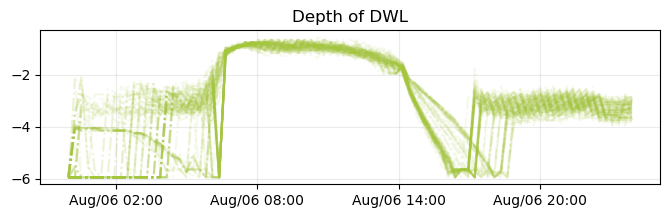

In [ ]:


fig2, ax2 = plt.subplots( figsize=(8, 2))

for i in range(Nm):
    ds = m1.ds.isel(Nens=i)
    dT = np.gradient(ds.C.values,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=1)
    md = np.array([ds.z[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')


    ax2.plot(m1.dates, -md , '-', color=colors[0], alpha=0.1)
    # c1 = axs[im].pcolormesh(models_list[model].dates,-m2024_11.ds.z, m2024_11.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)



format_date_ax(ax2, hours=6)
ax2.set_title("Depth of DWL")




In [7]:
# fig, axs = plt.subplots(figsize=(10, Nm*1.7), nrows=Nm, sharey=True, sharex=True)



# vmin, vmax = 27.5, 29.5
# # maxC = max(m2024_11.ds['C'].values.ravel())
# for i in range(Nm):
#     ds = m1.ds.isel(Nens=i)
#     ax2.plot(m1.dates, ds['C'].values.T, color=colors[i], label=i, alpha=0.6)


# for im, model in enumerate(models):

    
#     ds = models_list[model].ds
#     c1 = axs[im].pcolormesh(models_list[model].dates,-ds.z, ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
#     axs[im].set_title("Model with Wind x %s" % model)
#     axs[im].set_ylabel('Depth (m)')
# # c1 = axs[0].pcolormesh(m2024_01.dates,-m2024_01.ds.z, m2024_01.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)

# format_date_ax(axs[0], hours=5)
# format_date_ax(axs[1], hours=5)
# cb = add_colorbar(fig, c1)
# cb.set_label('Normalized Temperature (T/Tmax)')



# # plt.tight_layout()

In [8]:
# fig, axs = plt.subplots(figsize=(10,  Nm*1.7), nrows=Nm, sharey=True, sharex=True)

# print(models_list['1'].ds['Kz'].shape)
# average_diff = np.zeros((Nm,  models_list['1'].ds['Kz'].shape[0], models_list['1'].ds['Kz'].shape[1]))

# for im, model in enumerate(models):
#     ds = models_list[model].ds
#     c1 = axs[im].pcolormesh(models_list[model].dates,-ds['Kz'].z, ds['Kz'].values.T, cmap=cmo.cm.speed, norm=mpl.colors.LogNorm(vmin=10e-7, vmax=10e-2)) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
#     average_diff[im,:,:] = ds['Kz'].values 
#     axs[im].set_title("Model with Wind x %s" % model)
#     format_date_ax(axs[im], hours=6)

# average_diff = np.mean(average_diff, axis=0)
# cb = add_colorbar(fig, c1)
# axs[0].set_ylim(-4,0)

# axs[0].set_ylabel('Depth (m)')
# axs[1].set_ylabel('Depth (m)')

In [9]:
# fig, axs = plt.subplots(figsize=(10,  Nm*1.7), nrows=Nm, sharey=True, sharex=True)

# for im, model in enumerate(models):
#     ds = models_list[model].ds
#     kz = ds['Kz'].values - average_diff
#     c1 = axs[im].pcolormesh(models_list[model].dates,-ds['Kz'].z, kz.T, cmap=cmo.cm.balance, vmin=-1e-3, vmax=1e-3)# norm=mpl.colors.LogNorm(vmin=10e-7, vmax=10e-2)) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
#     axs[im].set_title("Model with Wind x %s" % model)
#     format_date_ax(axs[im], hours=6)

# cb = add_colorbar(fig, c1)

# axs[0].set_ylim(-4,0)

# axs[0].set_ylabel('Depth (m)')
# axs[1].set_ylabel('Depth (m)')

/tmp/ipykernel_167827/2718775721.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Text(0.5, 0.98, 'Diffusivity in the upper 2 m of the water column')

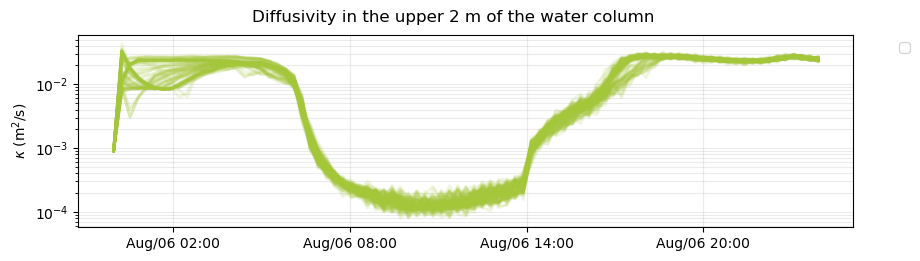

In [10]:
fig, axs = plt.subplots(figsize=(10, 2.5), nrows=1, sharey=True, sharex=False)

for i in range(Nm):
    ds = m1.ds.isel(Nens=i)

    kz = ds.Kz.sel(z=slice(2, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs.plot(m1.dates, kz_av, color=colors[0], alpha=0.15, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)
format_date_ax(axs, hours=6)

axs.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs.set_yscale("log")
axs.grid(alpha=0.25)
axs.set_ylabel(r'$\kappa$ (m$^2$/s)')
plt.suptitle("Diffusivity in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()


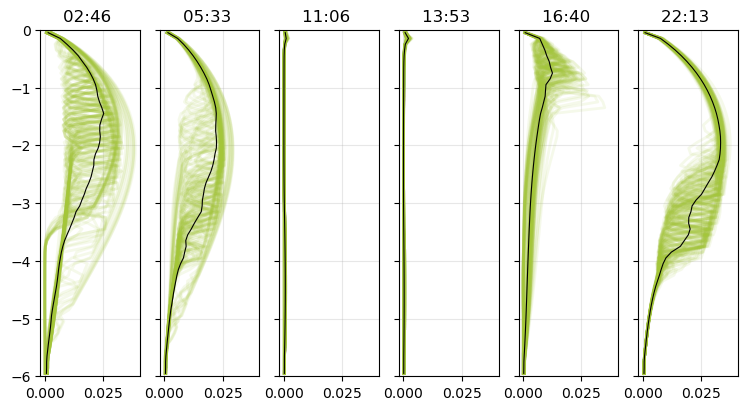

In [11]:
TIMES = [10, 20, 40, 50,  60, 80]

fig, axs = plt.subplots(figsize=(9, 4.5), nrows=1, ncols=len(TIMES), sharey=True, sharex=True)


for it, t in enumerate(TIMES): 
    # axs[it].set_xscale("log")
    for i in range(Nm):
        ds = m1.ds.isel(Nens=i, time=t)

        kz = ds.Kz #.isel(time=t)
        axs[it].plot( kz.values,-kz.z, color=colors[0], linewidth=2, alpha=0.1) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    average = m1.ds.Kz.isel(time=t).mean(dim='Nens') 

    axs[it].plot(average, -kz.z, color="k", label="Average", linewidth=0.8)
    axs[it].set_ylim(-6,0)
    axs[it].grid(alpha=0.3)
    axs[it].set_title("%s " % (m1.dates[t].strftime("%H:%M")))


Text(0.5, 0.98, 'algae2')

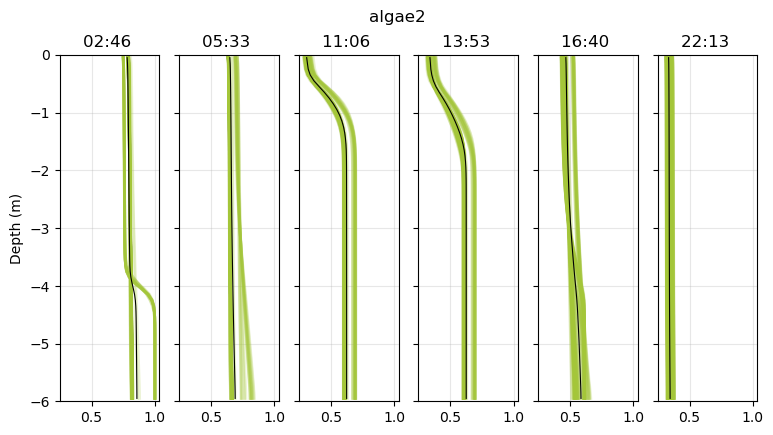

In [12]:

fig, axs = plt.subplots(figsize=(9, 4.5), nrows=1, ncols=len(TIMES), sharey=True, sharex=True)

variable = "algae2"
for it, t in enumerate(TIMES): 
    for i in range(Nm):
        ds = m1.ds.isel(Nens=i, time=t)
        kz = ds[variable]
        axs[it].plot( kz.values,-kz.z, color=colors[0], linewidth=2, alpha=0.2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    average = m1.ds[variable].isel(time=t).mean(dim='Nens') 

    axs[it].plot(average, -kz.z, color="k", label="Average", linewidth=0.8)
    axs[it].set_ylim(-6,0)
    axs[it].grid(alpha=0.3)
    axs[it].set_title("%s " % (m1.dates[t].strftime("%H:%M")))

axs[0].set_ylabel('Depth (m)')
fig.suptitle(variable)

Text(0.5, 0.98, 'Brunt-Vaisala frequency in the upper 2 m of the water column')

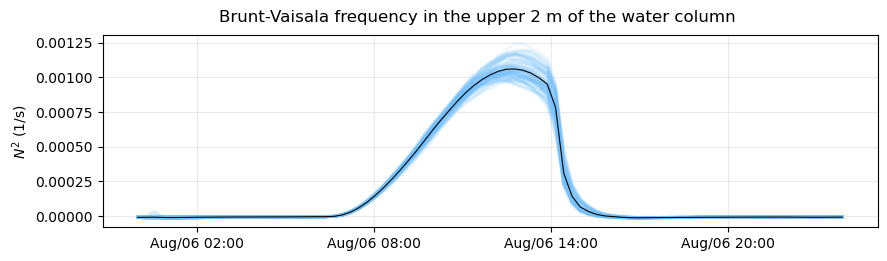

In [13]:
fig, axs = plt.subplots(figsize=(10, 2.5), nrows=1, sharey=True, sharex=False)

for i in range(Nm):
    ds = m1.ds.isel(Nens=i)
    kz = ds.N_BV2.sel(z=slice(2, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs.plot(m1.dates, kz_av, color=colors[1], alpha=0.1, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)

average = m1.ds.N_BV2.sel(z=slice(2, 0)).mean(dim="Nens").mean(dim="z")
axs.plot(m1.dates, average, color="k", label="Average", linewidth=0.8)
format_date_ax(axs, hours=6)

axs.grid(alpha=0.25)
axs.set_ylabel('$N^2$ (1/s)')
plt.suptitle("Brunt-Vaisala frequency in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()


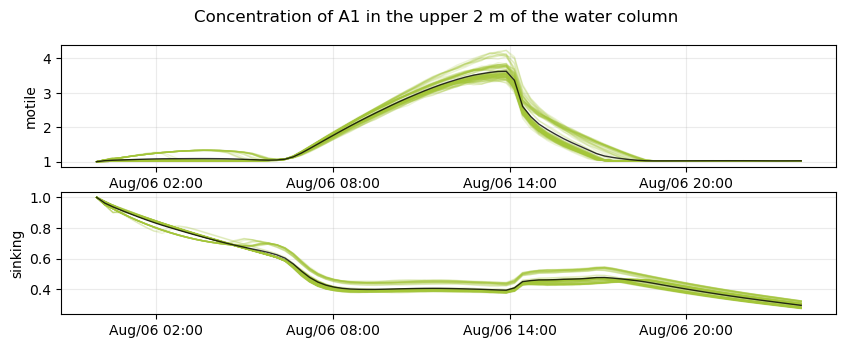

In [14]:
fig, axs = plt.subplots(figsize=(10, 3.5), nrows=2, sharey=False, sharex=False)

for i in range(Nm):
    ds = m1.ds.isel(Nens=i)
    var = ds.algae1.sel(z=slice(1, 0)) 
    var_av = var.mean(dim="z") 
    c1 = axs[0].plot(m1.dates, var_av, color=colors[0],  linewidth=1, alpha=0.2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
   

    var = ds.algae2.sel(z=slice(1, 0)) 
    var_av = var.mean(dim="z") 
    c1 = axs[1].plot(m1.dates, var_av, color=colors[0],  linewidth=1, alpha=0.2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
   
var = m1.ds.algae2.sel(z=slice(1, 0)).mean(dim="z").mean(dim="Nens")
c1 = axs[1].plot(m1.dates, var, color='k',  linewidth=1, alpha=0.8) 

var = m1.ds.algae1.sel(z=slice(1, 0)).mean(dim="z").mean(dim="Nens")
c1 = axs[0].plot(m1.dates, var, color='k',  linewidth=1, alpha=0.8) 

axs[0].set_ylabel('motile')
axs[1].set_ylabel('sinking')

for ax in axs:
    format_date_ax(ax, hours=6)
    ax.grid(alpha=0.25)
    plt.suptitle("Concentration of A1 in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()
